# Fixed point iters from quasi-deer

## Notes on sweep smnist_jax_tol

### Sweep id s9kqksg4 (sweeping over tolerance)

A lot of these jobs got preempted. Here are the seeds that survived

| Tol | Surviving Seeds | 
|----------|----------|
| 0.1 | 0 | 
| 0.01  | 1, 2 | 
| 0.001 | 1 | 

### Sweep id 78lsgavy

(Only looked at tol 1e-4)

Seeds 0,1 surived (for quasi-deer), but seed 2 got preempted

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pickle as p
import pandas as pd
import warnings

import jax.random as jr

warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

# Use TeX.
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
    }
)

# Configure font sizes.
SMALL_SIZE = 7 + 1
MEDIUM_SIZE = 8 + 1
BIGGER_SIZE = 10 + 1
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [65]:
with open("./01_17_smnist_sweep_78lsgavy.pkl", "rb") as f: # had tol 1e-4
    smnist_sweep = p.load(f)
with open("./01_17_tol_v2_s9kqksg4.pkl", "rb") as f:
    tol_sweep = p.load(f)

In [80]:
tol_sweep[~tol_sweep["val/accuracy"].isna()][["tol", "seed", "val/accuracy"]].groupby(["tol", "seed"]).max()

val/accuracy
tol   seed              
0.001 0         0.160482
      1         0.904088
      2         0.619931
0.010 0         0.893299
      1         0.861770
      2         0.888253
0.100 0         0.884394
      1         0.113281
      2         0.109026

In [81]:
# what happened to tol 0.01, seed 1?? (sunny-sweep-5)
# it really looks like something must have gotten messed up in your reloading code
tol_sweep[~tol_sweep["test/accuracy"].isna()][
    ["tol", "seed", "test/accuracy"]
]

,tol,seed,test/accuracy
12657,0.010,2,0.895898
25011,0.001,1,0.899707
31615,0.010,1,0.168359
54800,0.100,0,0.883398


<Axes: >

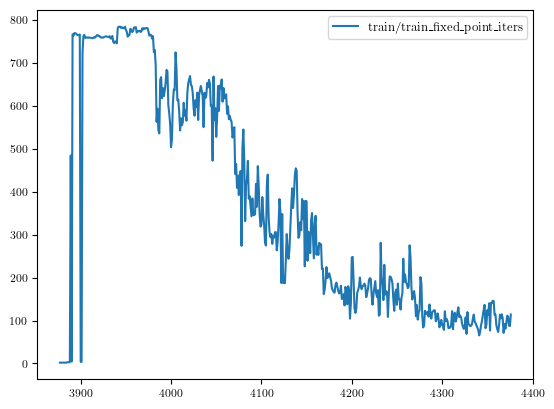

In [19]:
tol_sweep[tol_sweep["tol"] == 0.1][tol_sweep["seed"] == 0][
    ~tol_sweep["train/train_fixed_point_iters"].isna()
][["train/train_fixed_point_iters"]].plot()

seed
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
dtype: object

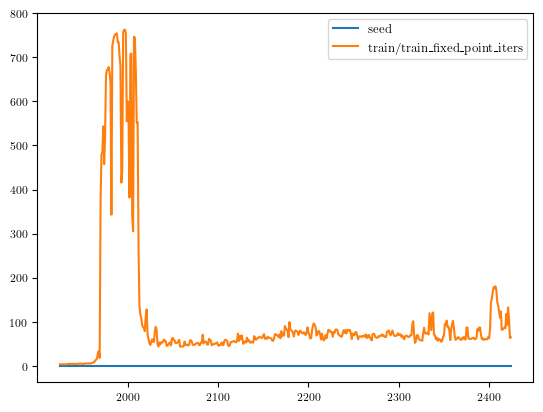

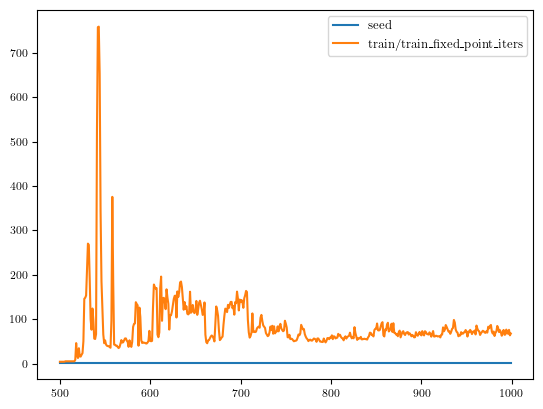

In [20]:
# qualitatively pretty similar, let's pick the seed at random
tol_sweep[tol_sweep["tol"] == 0.01][tol_sweep["seed"] > 0][
    ~tol_sweep["train/train_fixed_point_iters"].isna()
][["seed", "train/train_fixed_point_iters"]].groupby("seed").plot()

<Axes: >

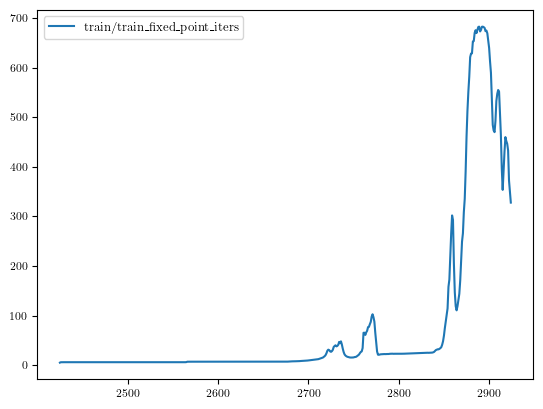

In [21]:
# uses around 6 fp iterations at the start, i.e. anything under 6 fp iterations represnts savings
tol_sweep[tol_sweep["tol"] == 0.001][tol_sweep["seed"] == 0][
    ~tol_sweep["train/train_fixed_point_iters"].isna()
][["train/train_fixed_point_iters"]].plot()

<Axes: >

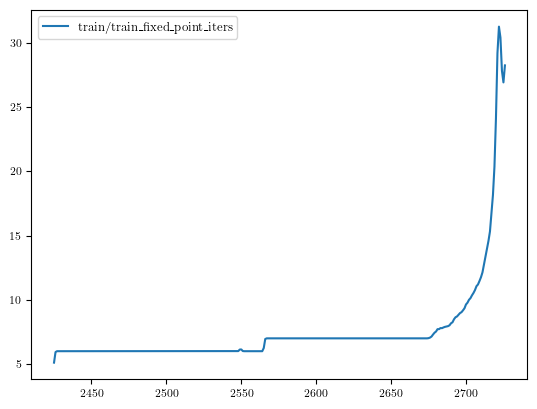

In [32]:
tol_sweep[tol_sweep["tol"] == 0.001][tol_sweep["seed"] == 0][
    ~tol_sweep["train/train_fixed_point_iters"].isna()
][["train/train_fixed_point_iters"]][:300].plot()

In [8]:
smnist_sweep['method']

0        quasideer
1        quasideer
2        quasideer
3        quasideer
4        quasideer
           ...    
33863          seq
33864          seq
33865          seq
33866          seq
33867          seq
Name: method, Length: 33868, dtype: object

Let's make a plot of quasi-deer fixed point iterations. Also get the number for average test accuracy.

seed
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
dtype: object

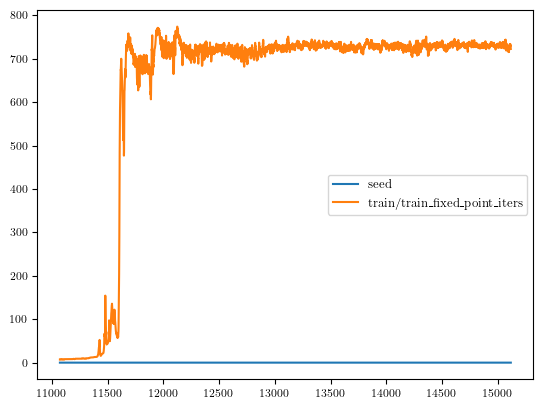

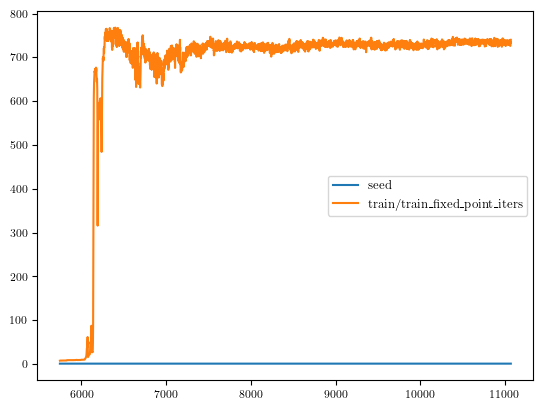

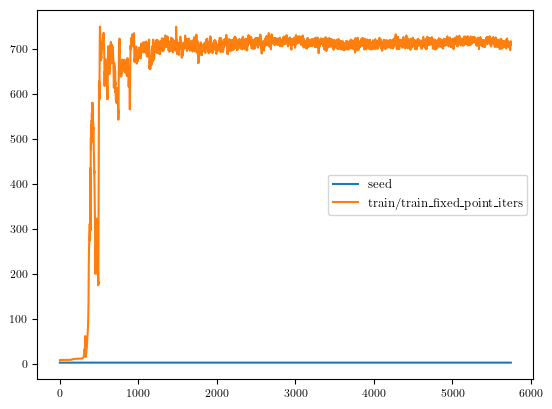

In [15]:
smnist_sweep[smnist_sweep['method']=='quasideer'][~smnist_sweep['train/train_fixed_point_iters'].isna()][['seed', 'train/train_fixed_point_iters']].groupby("seed").plot()

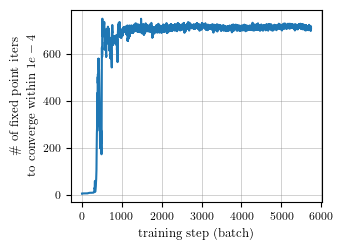

In [40]:
plt.figure(figsize=(3.25, 2.5))  # Set the figure size
plt.plot(
    smnist_sweep[smnist_sweep["method"] == "quasideer"][
        ~smnist_sweep["train/train_fixed_point_iters"].isna()
    ][smnist_sweep["seed"] == 2][["train/train_fixed_point_iters"]]
)
plt.xlabel("training step (batch)")
plt.ylabel(r"\# of fixed point iters \\ to converge within $1e-4$")
plt.grid(color="gray", linewidth=0.5, alpha=0.5)  # Add gray grid with light styling
plt.savefig("smnist_fixed_point_iters.pdf", bbox_inches="tight")
plt.show()

Let's get the average test accuracies for seq and quasi-deer now

In [34]:
smnist_sweep

,_step,_runtime,train/train_fixed_point_iters,_timestamp,train/train_batch_loss,train/train_loss,train/epoch,val/val_fixed_point_iters,val/epoch,val/accuracy,...,early_stopping_patience,dir_name,num_epochs,seed,learning_rate,fast_dev_run,test/epoch,test/test_loss,test/accuracy,test/test_fixed_point_iters
0,0.0,9.030607,7.000000,1.737070e+09,2.295847,NaN,NaN,NaN,NaN,NaN,...,5,data,100,2,0.001,False,NaN,NaN,NaN,NaN
1,1.0,9.230989,7.000000,1.737070e+09,2.307266,NaN,NaN,NaN,NaN,NaN,...,5,data,100,2,0.001,False,NaN,NaN,NaN,NaN
2,2.0,9.323909,7.000000,1.737070e+09,2.304088,NaN,NaN,NaN,NaN,NaN,...,5,data,100,2,0.001,False,NaN,NaN,NaN,NaN
3,3.0,9.399244,7.000000,1.737070e+09,2.297062,NaN,NaN,NaN,NaN,NaN,...,5,data,100,2,0.001,False,NaN,NaN,NaN,NaN
4,4.0,9.480776,7.058594,1.737070e+09,2.299290,NaN,NaN,NaN,NaN,NaN,...,5,data,100,2,0.001,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33863,6812.0,733.059201,1.000000,1.737070e+09,0.004134,NaN,NaN,NaN,NaN,NaN,...,5,data,100,0,0.001,False,NaN,NaN,NaN,NaN
33864,6813.0,733.163778,1.000000,1.737070e+09,0.024717,NaN,NaN,NaN,NaN,NaN,...,5,data,100,0,0.001,False,NaN,NaN,NaN,NaN
33865,6814.0,733.166112,NaN,1.737070e+09,NaN,0.00094,31.0,NaN,NaN,NaN,...,5,data,100,0,0.001,False,NaN,NaN,NaN,NaN
33866,6815.0,733.423451,NaN,1.737070e+09,NaN,NaN,NaN,1.0,31.0,0.987909,...,5,data,100,0,0.001,False,NaN,NaN,NaN,NaN


In [82]:
smnist_sweep[~smnist_sweep["test/accuracy"].isna()][['method', 'seed', 'test/accuracy']]

,method,seed,test/accuracy
11072,quasideer,1,0.847266
15120,quasideer,0,0.744434
23002,seq,1,0.972656
27050,seq,2,0.970703
33867,seq,0,0.986621


# Plot all tol

Let's make a plot of the number of fp iterations needed during training for a range of tolerances.

In [54]:
tol_sweep.columns

Index(['train/train_loss', '_step', 'train/train_fixed_point_iters',
       'val/val_loss', 'val/val_fixed_point_iters', '_runtime', '_timestamp',
       'val/accuracy', 'train/epoch', 'val/epoch', 'train/train_batch_loss',
       'run_id', 'early_stopping_metric', 'k', 'num_iters', 'use_wandb',
       'fast_dev_run', 'date', 'debug', 'method', 'dataset',
       'early_stopping_patience', 'tol', 'seed', 'early_stopping',
       'learning_rate', 'num_epochs', 'batch_size', 'model_type', 'dir_name',
       'hidden_size', 'early_stopping_min_delta', 'wandb_project',
       'test/test_loss', 'test/accuracy', 'test/epoch',
       'test/test_fixed_point_iters'],
      dtype='object')

In [64]:
tol_sweep[tol_sweep["tol"] == 0.1][tol_sweep["seed"] == 2]['train/epoch'].unique() # what happened to the logging?

array([nan,  0.,  1.])

In [ ]:
smnist_sweep[smnist_sweep["method"] == "quasideer"][smnist_sweep["seed"] == 0]['train/epoch'].unique() # logging was good

array([nan,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.,
       12., 13., 14., 15., 16., 17., 18.])

In [53]:
np.array(
    tol_sweep[tol_sweep["tol"] == 0.1][tol_sweep["seed"] == 0][["train/train_fixed_point_iters"]]
).shape

(500, 1)

In [67]:
jrseed = 0 # for deterministic randomness
key, new_key = jr.split(jr.PRNGKey(jrseed))
one = np.array(tol_sweep[tol_sweep["tol"] == 0.1][tol_sweep["seed"] == 0][
    ~tol_sweep["train/train_fixed_point_iters"].isna()
][["train/train_fixed_point_iters"]])
two = np.array(tol_sweep[tol_sweep["tol"] == 0.01][tol_sweep["seed"] == 1 + jr.bernoulli(key)][
    ~tol_sweep["train/train_fixed_point_iters"].isna()
][["train/train_fixed_point_iters"]])
three = np.array(tol_sweep[tol_sweep["tol"] == 0.001][tol_sweep["seed"] == 1][
    ~tol_sweep["train/train_fixed_point_iters"].isna()
][["train/train_fixed_point_iters"]])
key, new_key = jr.split(new_key)
four = np.array(smnist_sweep[smnist_sweep["method"] == "quasideer"][
    ~smnist_sweep["train/train_fixed_point_iters"].isna()
][smnist_sweep["seed"] == jr.bernoulli(key)][["train/train_fixed_point_iters"]])
plt_dict = {0.1: one,
            0.01: two,
            0.001: three,
            0.0001: four}

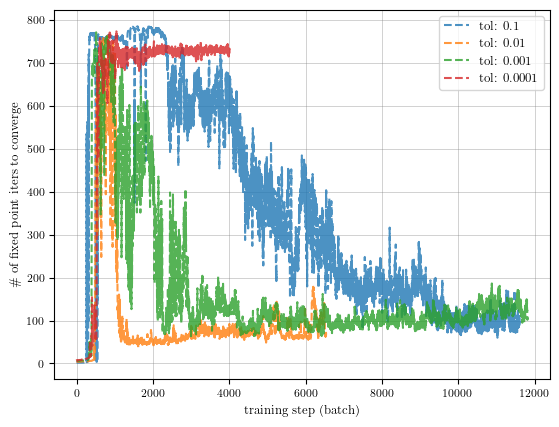

In [84]:
plt.figure(figsize=(3.25, 2.5))  # Set the figure size
for k,v in plt_dict.items():
    plt.plot(v, linestyle="--", label=f"tol: {k}", alpha=0.8)
plt.legend()
plt.grid(color="gray", linewidth=0.5, alpha=0.5)  # Add gray grid with light styling
plt.xlabel("training step (batch)")
plt.ylabel(r"\# of fixed point iters to converge")
plt.savefig("smnist_dif_tol.pdf", bbox_inches="tight")
plt.show()

In [50]:
len(four)

4009